In [ ]:
# Installing the necessary python libraries
!pip -q install scikit-learn pandas numpy matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# 1. Import libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

In [ ]:
# =========================
# 2. Upload dataset
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Original shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Saving dataset.csv to dataset.csv
Original shape: (1000, 17)
   user_id    user_role  department  years_of_experience login_timestamp  \
0        1        Nurse   Emergency                   28       10/3/2022   
1        2        Nurse  Cardiology                   17        1/5/2022   
2        3       Doctor   Neurology                   18       7/16/2022   
3        4  Admin Staff   Emergency                   27      10/14/2022   
4        5  Admin Staff  Cardiology                   26        6/4/2022   

   login_hour login_day_of_week    login_location device_type  \
0           3            Monday        Remote VPN      Tablet   
1          18            Sunday  Hospital Network      Mobile   
2          12          Thursday  Hospital Network      Tablet   
3          15            Friday  Hospital Network      Mobile   
4           5           Tuesday        Remote VPN     Desktop   

   daily_login_count  failed_login_attempts  records_accessed_count  \
0                  7

In [ ]:
# =========================
# 3. Clean column names
# =========================
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

print("Cleaned columns:")
print(df.columns.tolist())
print("Duplicates:", df.duplicated().sum())
print("Missing values:\n", df.isna().sum().sort_values(ascending=False).head(20))

Cleaned columns:
['user_id', 'user_role', 'department', 'years_of_experience', 'login_timestamp', 'login_hour', 'login_day_of_week', 'login_location', 'device_type', 'daily_login_count', 'failed_login_attempts', 'records_accessed_count', 'records_modified_count', 'sensitive_record_access', 'cross_department_access', 'session_duration_minutes', 'anomaly_label']
Duplicates: 0
Missing values:
 user_id                     0
user_role                   0
department                  0
years_of_experience         0
login_timestamp             0
login_hour                  0
login_day_of_week           0
login_location              0
device_type                 0
daily_login_count           0
failed_login_attempts       0
records_accessed_count      0
records_modified_count      0
sensitive_record_access     0
cross_department_access     0
session_duration_minutes    0
anomaly_label               0
dtype: int64


In [ ]:
# =========================
# 4. Find target safely
# =========================
possible_targets = ["anomalylabel", "anomaly_label", "label", "target"]
target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    raise KeyError(f"Target column not found. Available columns: {df.columns.tolist()}")

print("Target column:", target)

Target column: anomaly_label


In [ ]:
# =========================
# 5. Basic cleaning
# =========================
df = df.drop_duplicates().reset_index(drop=True)

df[target] = df[target].astype(str).str.strip().str.lower().map({
    "normal": 0,
    "suspicious": 1
})

binary_map = {"yes": 1, "no": 0, "y": 1, "n": 0, True: 1, False: 0}
for col in ["sensitiverecordaccess", "crossdepartmentaccess"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(binary_map)

print(df[[target]].value_counts(dropna=False))

anomaly_label
0                957
1                 43
Name: count, dtype: int64


In [ ]:
# =========================
# 6. Feature engineering
# =========================
if "sessiondurationminutes" in df.columns and "dailylogincount" in df.columns:
    df["session_per_login"] = df["sessiondurationminutes"] / (df["dailylogincount"] + 1)

if "recordsaccessedcount" in df.columns:
    df["high_access_flag"] = (df["recordsaccessedcount"] > df["recordsaccessedcount"].quantile(0.90)).astype(int)

if "failedloginattempts" in df.columns:
    df["failed_login_flag"] = (df["failedloginattempts"] > df["failedloginattempts"].quantile(0.90)).astype(int)

if "loginhour" in df.columns:
    df["after_hours"] = ((df["loginhour"] <= 6) | (df["loginhour"] >= 20)).astype(int)

if "recordsmodifiedcounts" in df.columns and "recordsaccessedcount" in df.columns:
    df["mod_access_ratio"] = df["recordsmodifiedcounts"] / (df["recordsaccessedcount"] + 1)

if "recordsmodifiedcounts" in df.columns and "dailylogincount" in df.columns:
    df["mod_per_login"] = df["recordsmodifiedcounts"] / (df["dailylogincount"] + 1)

if "failedloginattempts" in df.columns and "dailylogincount" in df.columns:
    df["failed_per_login"] = df["failedloginattempts"] / (df["dailylogincount"] + 1)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (1000, 17)


In [ ]:
# =========================
# 7. Split X and y
# =========================
y = df[target]
X = df.drop(columns=[target])

# Keep only numeric after encoding
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Force numeric and handle missing values
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("Final X shape:", X.shape)
print("Any object columns left?", X.select_dtypes(include=["object"]).columns.tolist())

Categorical columns: ['user_role', 'department', 'login_timestamp', 'login_day_of_week', 'login_location', 'device_type', 'sensitive_record_access', 'cross_department_access']
Final X shape: (1000, 372)
Any object columns left? []


In [ ]:
# =========================
# 8. Scale and split
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution train:", np.bincount(y_train))
print("Class distribution test:", np.bincount(y_test))

Train shape: (800, 372)
Test shape: (200, 372)
Class distribution train: [766  34]
Class distribution test: [191   9]


In [ ]:
from google.colab import files
# save the preprocessed dataframe
df.to_csv("preprocessed_dataset.csv", index=False)
# download to your local system
files.download("preprocessed_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# 9. Isolation Forest
# =========================
iso = IsolationForest(
    n_estimators=400,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

train_pred_iso = (iso.predict(X_train) == -1).astype(int)
test_pred_iso = (iso.predict(X_test) == -1).astype(int)

print("Isolation Forest - Accuracy:", accuracy_score(y_test, test_pred_iso))
print("Isolation Forest - Precision:", precision_score(y_test, test_pred_iso, zero_division=0))
print("Isolation Forest - Recall:", recall_score(y_test, test_pred_iso, zero_division=0))
print("Isolation Forest - F1:", f1_score(y_test, test_pred_iso, zero_division=0))
print(classification_report(y_test, test_pred_iso, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred_iso))

Isolation Forest - Accuracy: 0.915
Isolation Forest - Precision: 0.0
Isolation Forest - Recall: 0.0
Isolation Forest - F1: 0.0
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       191
           1       0.00      0.00      0.00         9

    accuracy                           0.92       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.91      0.92      0.91       200

Confusion matrix:
 [[183   8]
 [  9   0]]


In [ ]:
# =========================
# 10. Supervised benchmark: Random Forest
# =========================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest - Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest - Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Random Forest - Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("Random Forest - F1:", f1_score(y_test, rf_pred, zero_division=0))
print(classification_report(y_test, rf_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest - Accuracy: 0.955
Random Forest - Precision: 0.0
Random Forest - Recall: 0.0
Random Forest - F1: 0.0
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       191
           1       0.00      0.00      0.00         9

    accuracy                           0.95       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.91      0.95      0.93       200

Confusion matrix:
 [[191   0]
 [  9   0]]


In [ ]:
# =========================
# 11. Supervised benchmark: XGBoost
# =========================
!pip -q install xgboost

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)

xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

print("XGBoost - Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost - Precision:", precision_score(y_test, xgb_pred, zero_division=0))
print("XGBoost - Recall:", recall_score(y_test, xgb_pred, zero_division=0))
print("XGBoost - F1:", f1_score(y_test, xgb_pred, zero_division=0))
print(classification_report(y_test, xgb_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_pred))

XGBoost - Accuracy: 0.95
XGBoost - Precision: 0.0
XGBoost - Recall: 0.0
XGBoost - F1: 0.0
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       191
           1       0.00      0.00      0.00         9

    accuracy                           0.95       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.91      0.95      0.93       200

Confusion matrix:
 [[190   1]
 [  9   0]]


In [ ]:
# =========================
# 12. Autoencoder
# =========================
!pip -q install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
9
X_train_normal = X_train[y_train == 0]
input_dim = X_train.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

recon_train = autoencoder.predict(X_train, verbose=0)
recon_test = autoencoder.predict(X_test, verbose=0)

train_mse = np.mean(np.square(X_train - recon_train), axis=1)
test_mse = np.mean(np.square(X_test - recon_test), axis=1)

threshold_ae = np.percentile(train_mse, 95)
ae_pred = (test_mse > threshold_ae).astype(int)

print("Autoencoder - Accuracy:", accuracy_score(y_test, ae_pred))
print("Autoencoder - Precision:", precision_score(y_test, ae_pred, zero_division=0))
print("Autoencoder - Recall:", recall_score(y_test, ae_pred, zero_division=0))
print("Autoencoder - F1:", f1_score(y_test, ae_pred, zero_division=0))
print(classification_report(y_test, ae_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, ae_pred))

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.0262 - val_loss: 1.0120
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0206 - val_loss: 1.0115
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0180 - val_loss: 1.0109
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0144 - val_loss: 1.0095
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0087 - val_loss: 1.0078
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0002 - val_loss: 1.0058
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9889 - val_loss: 1.0038
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9777 - val_loss: 1.0025
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9661 - val_loss: 1.0006
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9551 - val_loss: 0.9985
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9455 - val_loss: 0.9976
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9372 - v

In [ ]:
# =========================
# 13. Compare all models
# =========================
results = pd.DataFrame({
    "Model": [
        "IsolationForest",
        "RandomForest",
        "XGBoost",
        "Autoencoder"
    ],
    "Accuracy": [
        accuracy_score(y_test, test_pred_iso),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, ae_pred)
    ],
    "Precision": [
        precision_score(y_test, test_pred_iso, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, xgb_pred, zero_division=0),
        precision_score(y_test, ae_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, test_pred_iso, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, xgb_pred, zero_division=0),
        recall_score(y_test, ae_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, test_pred_iso, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, xgb_pred, zero_division=0),
        f1_score(y_test, ae_pred, zero_division=0)
    ]
})

print(results.sort_values("F1", ascending=False))
results.to_csv("all_model_comparison.csv", index=False)

             Model  Accuracy  Precision    Recall        F1
3      Autoencoder     0.925      0.125  0.111111  0.117647
0  IsolationForest     0.915      0.000  0.000000  0.000000
1     RandomForest     0.955      0.000  0.000000  0.000000
2          XGBoost     0.950      0.000  0.000000  0.000000


<Figure size 1000x500 with 0 Axes>

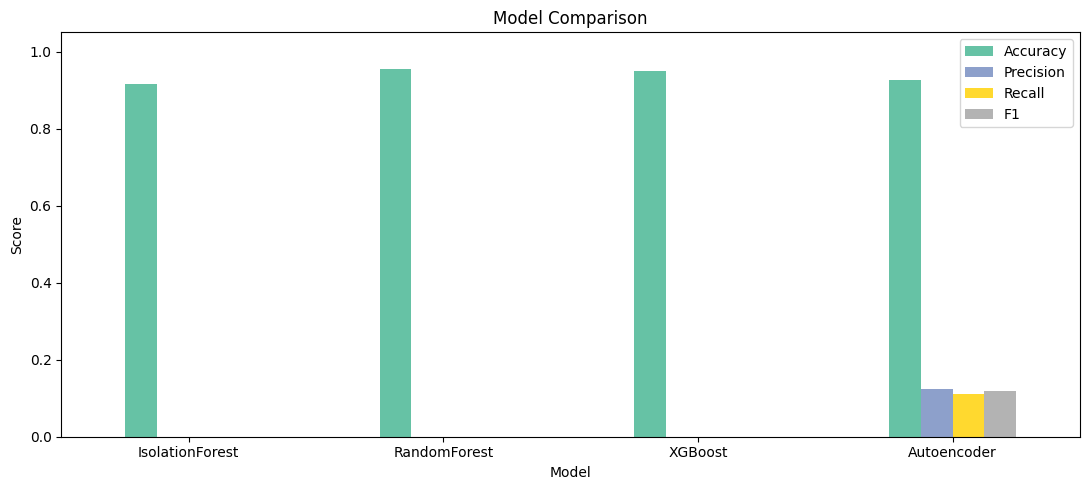

In [ ]:
# =========================
# 14. Plot comparison
# =========================
plt.figure(figsize=(10, 5))
plot_df = results.set_index("Model")
plot_df[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("all_model_comparison.png", dpi=300)
plt.show()

In [ ]:
# =========================
# 15. Best model selection
# =========================
best_model_row = results.sort_values("F1", ascending=False).iloc[0]
print("Best model based on F1:", best_model_row["Model"])
print(best_model_row)

Best model based on F1: Autoencoder
Model        Autoencoder
Accuracy           0.925
Precision          0.125
Recall          0.111111
F1              0.117647
Name: 3, dtype: object


/tmp/ipykernel_1836/2045262702.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(top_n), x="importance", y="feature", palette="viridis")


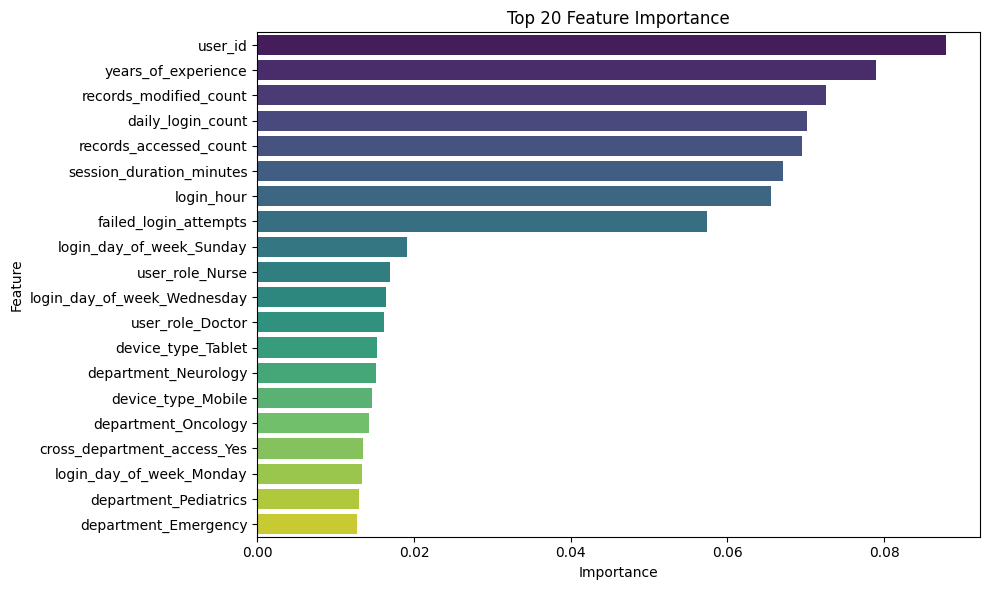

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the trained Random Forest model
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Save to CSV
feat_imp.to_csv("feature_importance.csv", index=False)

# Plot top 20 features
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(top_n), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_graph.png", dpi=300)
plt.show()